**In this Notebook we will do the following:**

- Construct the Pauli-Transfer-Matrix (PTM) of multiple Circuits
    - Memory Round: Surface Code
    - Lattice Surgery

- Invert the PTM to get an estimate of the Logical Operator

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, pathlib

repo_root = pathlib.Path.cwd()

# If running from the playground directory, move up one level to the repo root
if repo_root.name == 'playground':
    repo_root = repo_root.parent

sys.path.insert(0, str(repo_root))
print('Inserted repo root into sys.path:', repo_root)

Inserted repo root into sys.path: /Users/fabian/qecsim


In [3]:
from src.core.data_models import NoiseParameters
from src.tools.qem_estimator.logical_level.calc_ptm import PTMCalculator
from src.core.data_models import PTMCircuits
from src.codes.lattice_surgery.builder import SurgeryBuilder
from itertools import product
from tqdm import tqdm
import gc

import stim

**PTM Calculation: Lattice Surgery**

**Logical-Estimator**

We now use the Noisy and the Ideal PTM in order to build the logical estimator

**Overhead-Factor/ Physical Error Probability**

In [14]:
import sinter
import os

In [15]:
import math

# geomspace replacement
geom = [10**(math.log10(1e-5) + i*(math.log10(1e-3) - math.log10(1e-5))/9) for i in range(10)]

# linspace replacement
lin = [1.1e-3 + i*(0.015 - 1.1e-3)/39 for i in range(40)]

p_values = geom + lin

In [18]:
import itertools
from tqdm import tqdm

distances = [3, 5, 7]

combinations = list(itertools.product(distances, p_values))

# 3. Build the tasks with a progress bar
tasks = [
    sinter.Task(
        circuit=SurgeryBuilder(
            distance=d,
            control_state_init="X+",
            target_state_init="I0",
            control_measure_basis="X",
            target_measure_basis="X",
            noise=NoiseParameters(
                before_round_depol=noise,
                before_m_flip_prob=noise,
                after_r_flip=noise,
                after_c_depol_prob=noise
            )
        ).build_circuit(),
        json_metadata={'d': d, 'p': noise},
    )
    for d, noise in tqdm(combinations, desc="Building Circuits")
]

# 4. Now hand them off to sinter
collected_stats = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=100_000,
    max_errors=500,
    print_progress=True
)

Building Circuits: 100%|██████████| 150/150 [19:17<00:00,  7.72s/it]
Starting 8 workers...
150 tasks left:
  workers    decoder eta shots_left errors_left json_metadata               
        1 pymatching <1m      93583         500 d=3,p=1e-05                 
        1 pymatching   ?     100000         500 d=3,p=1.6681005372000593e-05
        1 pymatching   ?     100000         500 d=3,p=2.782559402207126e-05 
        1 pymatching   ?     100000         500 d=3,p=4.641588833612782e-05 
        1 pymatching   ?     100000         500 d=3,p=7.742636826811278e-05 
        1 pymatching   ?     100000         500 d=3,p=0.0001291549665014884 
        1 pymatching   ?     100000         500 d=3,p=0.00021544346900318823
        1 pymatching   ?     100000         500 d=3,p=0.00035938136638046257
        0 pymatching ?·∞     100000         500 d=3,p=0.0005994842503189409 
        0 pymatching ?·∞     100000         500 d=3,p=0.001                 
        0 pymatching ?·∞     100000         50

In [66]:
with open("surgery_threshold_standard.csv", "w") as f:
    # 1. Write the mandatory header
    print(sinter.CSV_HEADER, file=f)
    
    # 2. Write each task result as a CSV line
    for stat in collected_stats:
        print(stat.to_csv_line(), file=f)

In [67]:
from matplotlib import pyplot as plt

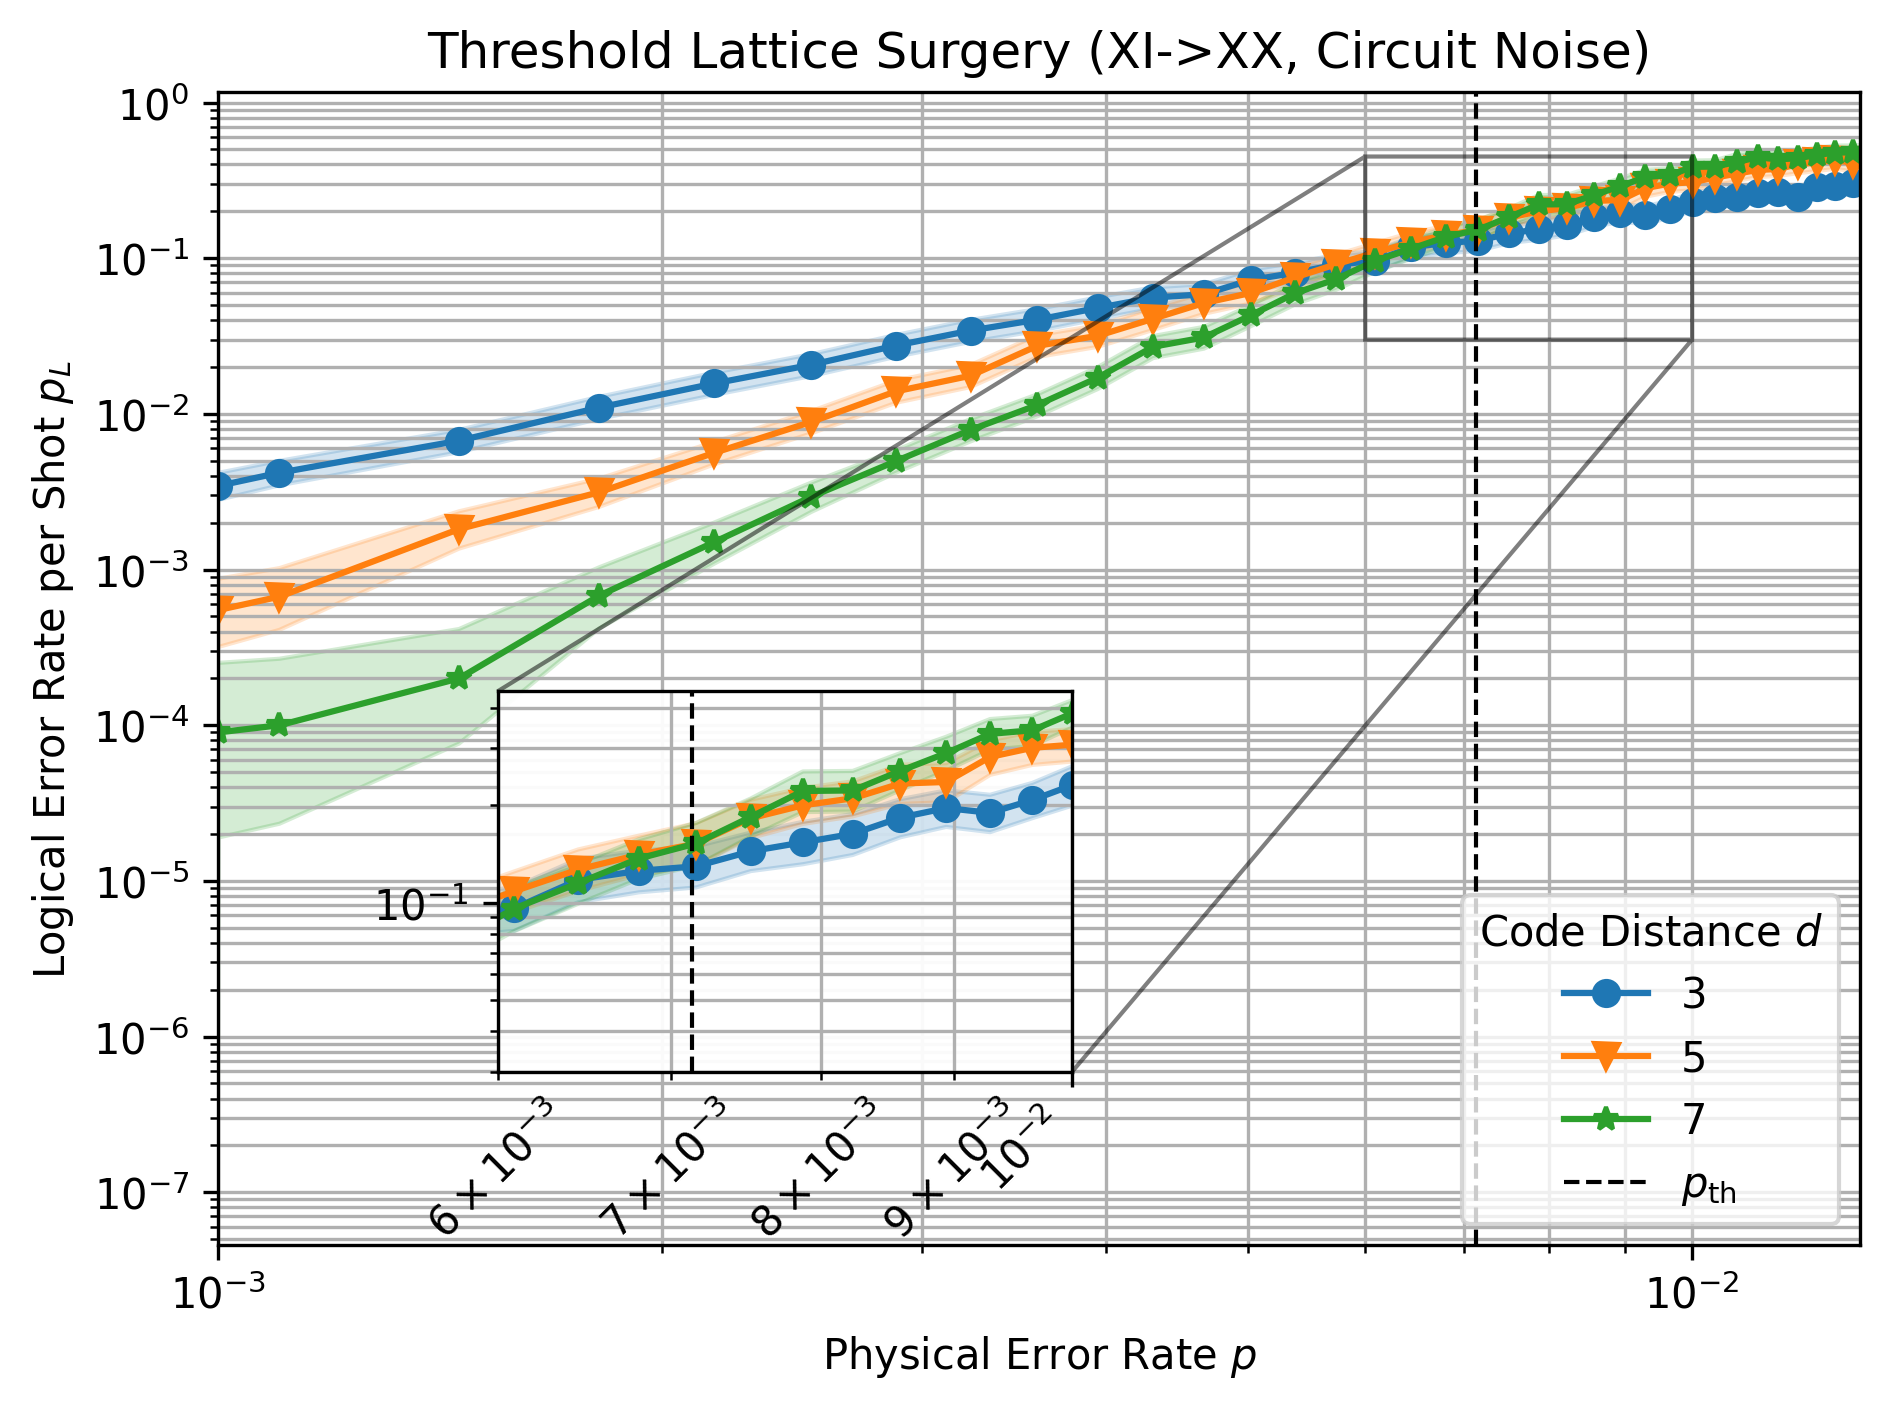

In [92]:
p_th = 0.713e-2

############################################
# Main Plot: Error Rates (Phenomenological)
############################################

fig, ax = plt.subplots(1, 1)

sinter.plot_error_rate(
    ax=ax,
    stats=collected_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d']
)

# Threshold line
ax.axvline(
    x=p_th,
    color="black",
    linestyle="--",
    linewidth=1,
    label=r"$p_{\mathrm{th}}$"
)

# Style main axes
ax.set_xlim(1e-3, 1.3e-2)
ax.loglog()
ax.set_title("Threshold Lattice Surgery (XI->XX, Circuit Noise)")
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate per Shot $p_L$")
ax.grid(which='major')
ax.grid(which='minor')

# Legend in the bottom right
ax.legend(title="Code Distance $d$", loc='lower right')

############################################
# Plotting Zoomed in Section (Bottom Left)
############################################

# [x0, y0, width, height]
# x0=0.15 shifts it right to avoid main y-axis labels
# y0=0.12 shifts it up to avoid main x-axis labels
axins = ax.inset_axes([0.17, 0.15, 0.35, 0.33])

sinter.plot_error_rate(
    ax=axins,
    stats=collected_stats,
    x_func=lambda s: s.json_metadata['p'],
    group_func=lambda s: s.json_metadata['d'])

# Threshold line in zoom
axins.axvline(x=p_th, color="black", linestyle="--", linewidth=1)

# Zoom window limits
x1, x2, y1, y2 = 0.6e-2, 1.0e-2, 3e-2, 4.5e-1 
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.loglog()

# Style the inset
axins.grid(which='major')
axins.grid(which='minor')
axins.patch.set_facecolor("white")
axins.patch.set_alpha(0.95)

# Add the indicator boxes/lines
ax.indicate_inset_zoom(axins, edgecolor="black")

# Rotate X-labels for clarity in the small window
axins.tick_params(axis='x', which='both', rotation=45)
for lbl in axins.get_xticklabels():
    lbl.set_ha('right') 

# Final figure settings
fig.set_dpi(300)
plt.tight_layout()

# Save as PDF
# bbox_inches='tight' ensures that labels or the inset box aren't cut off
plt.savefig("lattice_surgery_threshold.pdf", bbox_inches='tight')

# Show the plot
plt.show()

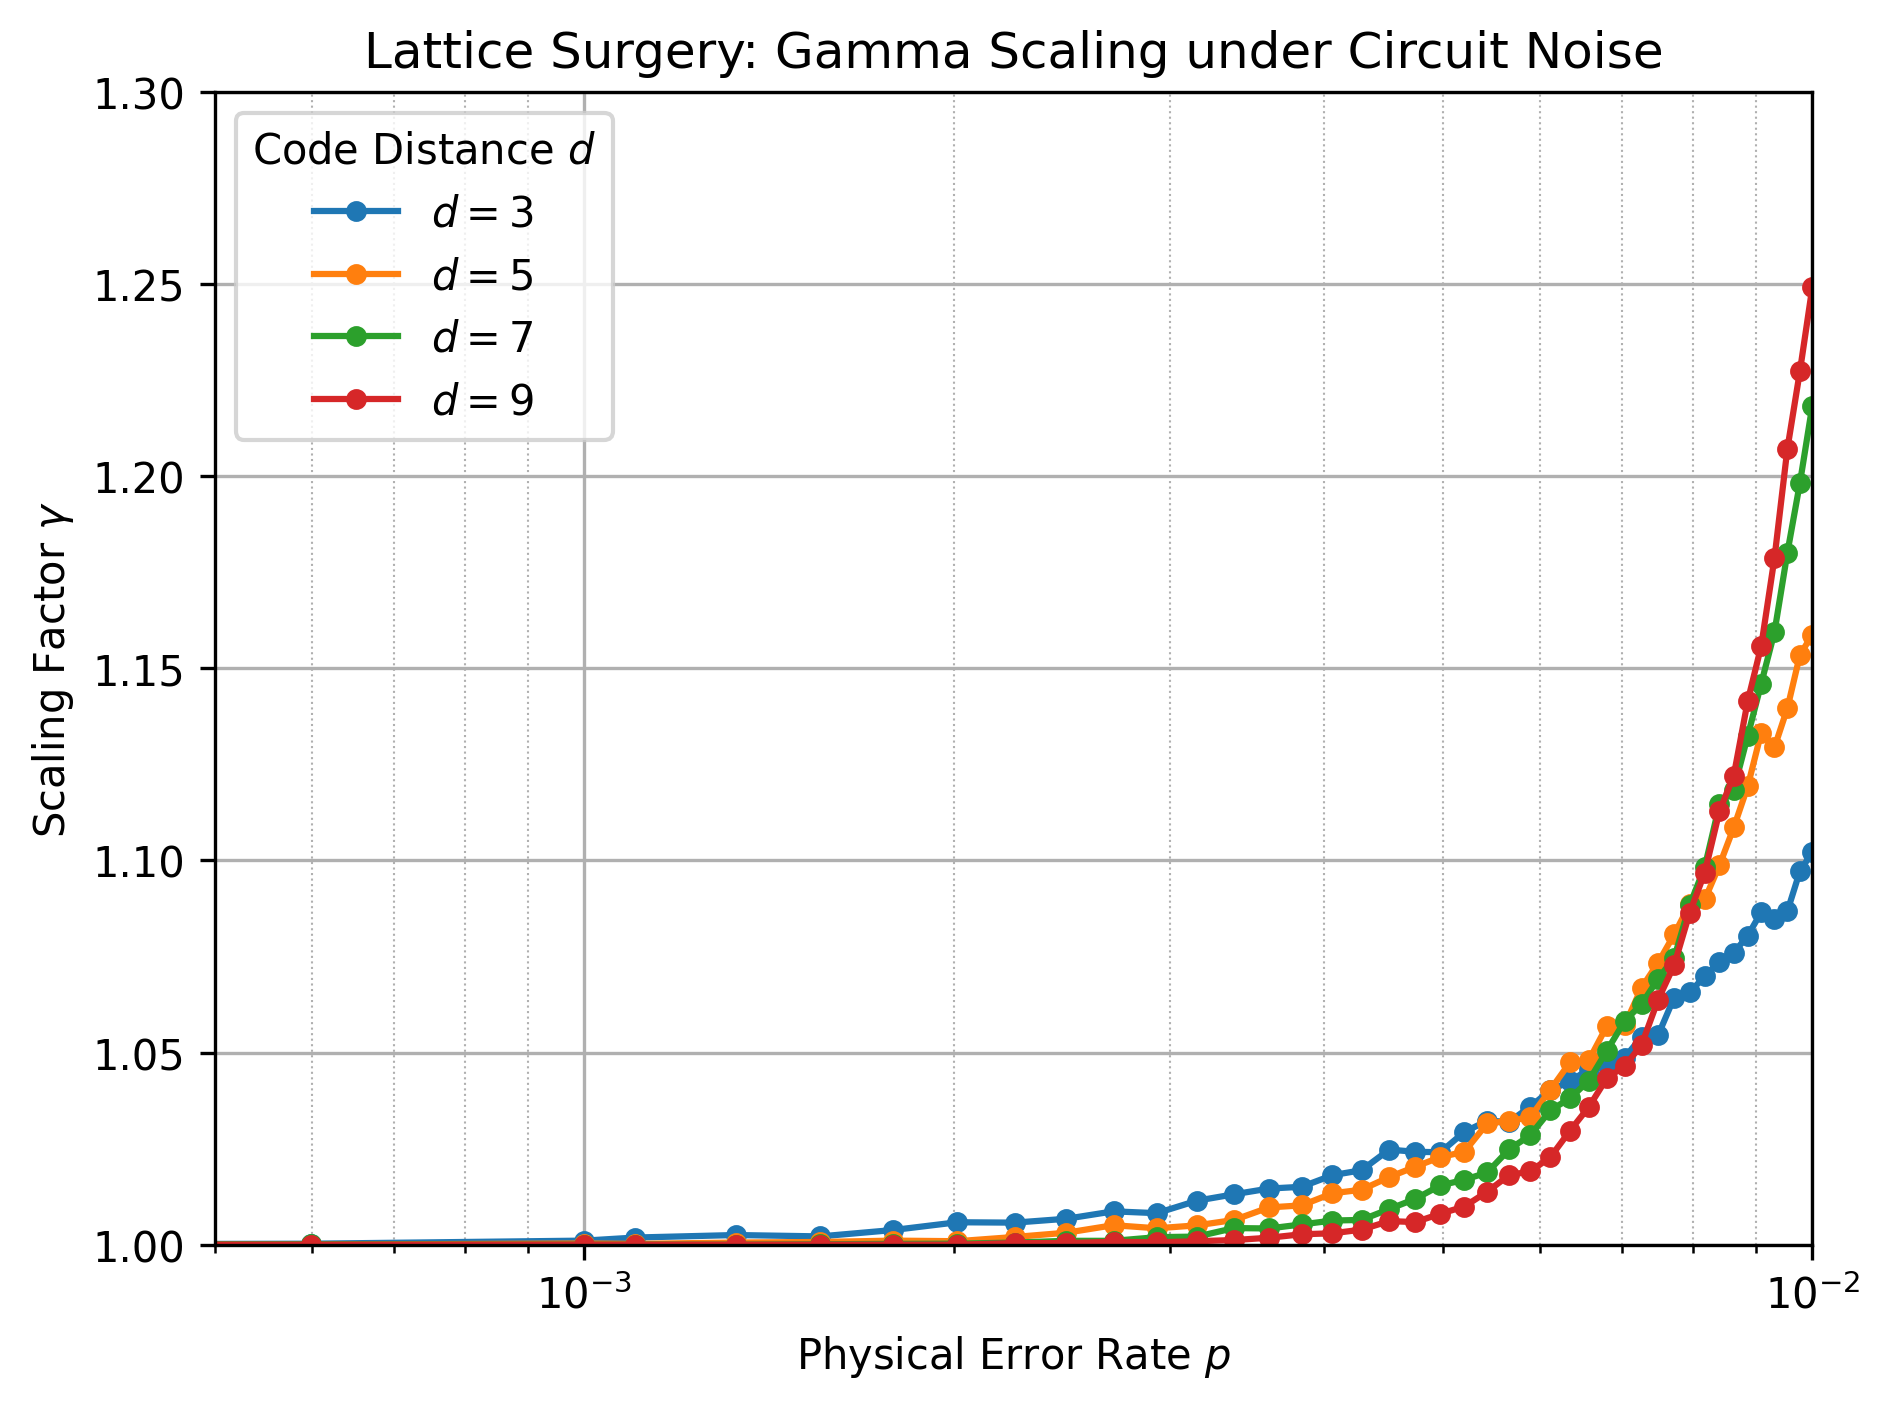

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_csv('gamma_memory.csv')

# 2. Setup the main plot
fig, ax = plt.subplots(1, 1)

for distance, group in df.groupby('distance'):
    ax.plot(
        group['physical_error_probability'], 
        group['gamma'], 
        marker='o', 
        markersize=4,
        label=r"$d={}$".format(distance)
    )

# 3. Main Axis Formatting
ax.set_ylim(1.0, 1.3)
ax.set_xlim(5e-4, 1e-2)
ax.set_xscale('log') 
ax.set_title("Lattice Surgery: Gamma Scaling under Circuit Noise")
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel(r"Scaling Factor $\gamma$")

ax.grid(which='major', linestyle='-', linewidth=0.8)
ax.grid(which='minor', linestyle=':', linewidth=0.5)

# Moved legend to upper right to avoid the inset box
ax.legend(title="Code Distance $d$", loc='upper left')

# 5. Final output
fig.set_dpi(300)
plt.tight_layout()

# Save as PDF
plt.savefig("gamma_memory_d3579.pdf", bbox_inches='tight')

plt.show()

In [2]:
import numpy as np

In [5]:
# Calculate the infidelities around the threshold for the d=5,7 lattice surgery cases

# Load the matrices for d=5 and d=7
ptm_d5_ideal = np.load("../ptm_matrices_memory/ptm_ideal_d5_CircuitNoise.npy")
ptm_d7_ideal = np.load("../ptm_matrices_memory/ptm_ideal_d7_CircuitNoise.npy")

# Load Noisy PTMs around 7e-3
probs = np.linspace(1.1e-3, 1e-2, 40)
ptm_d5_noisy = [np.load(f"../ptm_matrices_memory/ptm_noisy_d5_p{p:.2e}_CircuitNoise.npy") for p in probs]
ptm_d7_noisy = [np.load(f"../ptm_matrices_memory/ptm_noisy_d7_p{p:.2e}_CircuitNoise.npy") for p in probs]

def calculate_infidelity(ptm_ideal, ptm_noisy):
    # Ensure the first element is 1 for both matrices
    ptm_ideal = ptm_ideal.copy()
    ptm_noisy = ptm_noisy.copy()
    ptm_ideal[0, 0] = 1
    ptm_noisy[0, 0] = 1


    fidelity = np.trace(ptm_ideal @ ptm_noisy) / 4
    return 1 - fidelity

# Calculate infidelities for d=5 and d=7
infidelities_d5 = [calculate_infidelity(ptm_d5_ideal, ptm_noisy) for ptm_noisy in ptm_d5_noisy]
infidelities_d7 = [calculate_infidelity(ptm_d7_ideal, ptm_noisy) for ptm_noisy in ptm_d7_noisy]

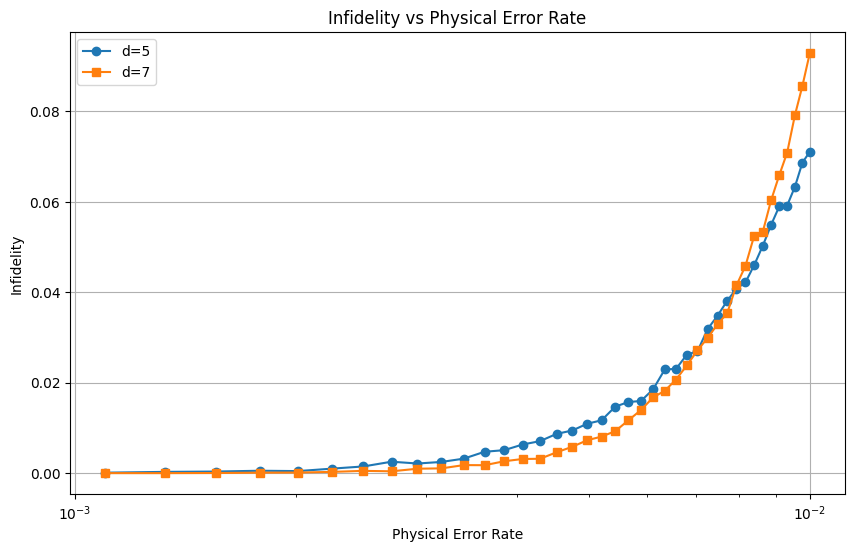

In [6]:
# Plotting infidelity vs physical error rate
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(probs, infidelities_d5, 'o-', label='d=5')
plt.plot(probs, infidelities_d7, 's-', label='d=7')
plt.xscale('log')
plt.xlabel('Physical Error Rate')
plt.ylabel('Infidelity')
plt.title('Infidelity vs Physical Error Rate')
plt.legend()
plt.grid(True)

# Save plot as PDF
plt.savefig("infidelity_vs_physical_error_rate_memory.pdf", bbox_inches='tight')

# Show the plot
plt.show()


Calculating overhead for d=5...
Calculating overhead for d=7...


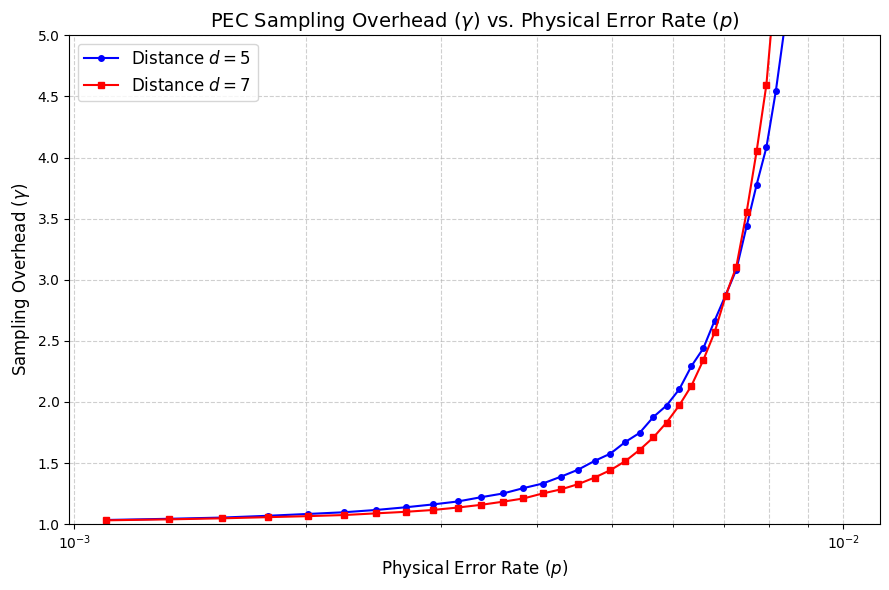

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from src.tools.qem_estimator.logical_level.logical_estimator import GeneralLogicalEstimator

# --- 1. Load Data (From your snippet) ---
ptm_d5_ideal = np.load("../ptm_matrices/ptm_ideal_d5_CircuitNoise.npy")
ptm_d7_ideal = np.load("../ptm_matrices/ptm_ideal_d7_CircuitNoise.npy")

probs = np.linspace(1.1e-3, 1e-2, 40)
ptm_d5_noisy = [np.load(f"../ptm_matrices/ptm_noisy_d5_p{p:.2e}_CircuitNoise.npy") for p in probs]
ptm_d7_noisy = [np.load(f"../ptm_matrices/ptm_noisy_d7_p{p:.2e}_CircuitNoise.npy") for p in probs]

# Ensure TP
ptm_d5_ideal[0, 0] = 1
ptm_d7_ideal[0, 0] = 1

# --- 2. Calculate Gammas ---
gamma_d5 = []
gamma_d7 = []

print("Calculating overhead for d=5...")
for ptm_noisy in ptm_d5_noisy:
    ptm_noisy[0, 0] = 1
    estimator_d5 = GeneralLogicalEstimator(ptm_noisy, ptm_d5_ideal)
    estimator_d5.setup_estimator()
    gamma_d5.append(estimator_d5.gamma)

print("Calculating overhead for d=7...")
for ptm_noisy in ptm_d7_noisy:
    ptm_noisy[0, 0] = 1
    estimator_d7 = GeneralLogicalEstimator(ptm_noisy, ptm_d7_ideal)
    estimator_d7.setup_estimator()
    gamma_d7.append(estimator_d7.gamma)

# --- 3. Plotting ---
plt.figure(figsize=(9, 6))

# Plot both distances
plt.plot(probs, gamma_d5, marker='o', markersize=4, label='Distance $d=5$', color='blue')
plt.plot(probs, gamma_d7, marker='s', markersize=4, label='Distance $d=7$', color='red')

# Formatting
plt.title('PEC Sampling Overhead ($\gamma$) vs. Physical Error Rate ($p$)', fontsize=14)
plt.xlabel('Physical Error Rate ($p$)', fontsize=12)
plt.ylabel('Sampling Overhead ($\gamma$)', fontsize=12)

# Log scale is standard for Gamma as it scales exponentially with noise
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.xscale('log')
plt.ylim(1,5)
plt.legend(fontsize=12)
plt.tight_layout()

# Show and/or save the plot
# plt.savefig("pec_overhead_comparison.png", dpi=300)
plt.show()